In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
os.listdir()

['.ipynb_checkpoints',
 'AdventureWorks Calendar Lookup.csv',
 'AdventureWorks Product Lookup.csv',
 'AdventureWorks Sales Data 2022(1).csv',
 'AdventureWorks Territory Lookup.csv',
 'phots new',
 'power bi.1.pbix',
 'power bi.2.pbix',
 'sales_data.csv',
 'sending phots',
 'Untitled.ipynb',
 'Untitled1.ipynb',
 'Untitled2.ipynb',
 'Untitled3.ipynb',
 'Untitled4.ipynb',
 'Untitled5.ipynb',
 'Untitled6.ipynb']

In [3]:
Sales = pd.read_csv("AdventureWorks Sales Data 2022(1).csv")
products = pd.read_csv("AdventureWorks Product Lookup.csv")
Territory = pd.read_csv("AdventureWorks Territory Lookup.csv")

In [5]:
Sales.head()

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
0,2022-01-01,2021-12-13,SO61285,529,23791,1,2,2
1,2022-01-01,2021-09-24,SO61285,214,23791,1,3,1
2,2022-01-01,2021-09-04,SO61285,540,23791,1,1,1
3,2022-01-01,2021-09-28,SO61301,529,16747,1,2,2
4,2022-01-01,2021-10-21,SO61301,377,16747,1,1,1


In [30]:
products.head()
Territory.head()


,SalesTerritoryKey,Region,Country,Continent
0,1,Northwest,United States,North America
1,2,Northeast,United States,North America
2,3,Central,United States,North America
3,4,Southwest,United States,North America
4,5,Southeast,United States,North America


In [6]:
Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29481 entries, 0 to 29480
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   OrderDate      29481 non-null  object
 1   StockDate      29481 non-null  object
 2   OrderNumber    29481 non-null  object
 3   ProductKey     29481 non-null  int64 
 4   CustomerKey    29481 non-null  int64 
 5   TerritoryKey   29481 non-null  int64 
 6   OrderLineItem  29481 non-null  int64 
 7   OrderQuantity  29481 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 1.8+ MB


In [7]:
Sales.shape

(29481, 8)

In [9]:
Sales.columns

Index(['OrderDate', 'StockDate', 'OrderNumber', 'ProductKey', 'CustomerKey',
       'TerritoryKey', 'OrderLineItem', 'OrderQuantity'],
      dtype='object')

In [10]:
Sales.isnull().sum()

OrderDate        0
StockDate        0
OrderNumber      0
ProductKey       0
CustomerKey      0
TerritoryKey     0
OrderLineItem    0
OrderQuantity    0
dtype: int64

In [13]:
    Sales["OrderQuantity"].sum()

np.int64(45314)

In [14]:
Sales["OrderNumber"].nunique()

11839

In [19]:
qty = np.array(Sales["OrderQuantity"])
np.mean(qty)

np.float64(0.61723832911973)

In [17]:
np.max(qty)

np.int64(3)

In [18]:
np.min(qty)

np.int64(1)

In [20]:
np.std(qty)

np.float64(0.61723832911973)

In [21]:
merged = pd.merge(Sales,products,on="ProductKey",how="inner")

In [22]:
top_products = merged.groupby("ProductName")["OrderQuantity"].sum() 
top_products = top_products.sort_values(
    ascending=False
).head(10)
print(top_products)

ProductName
Water Bottle - 30 oz.    4565
Patch Kit/8 Patches      3255
Mountain Tire Tube       3121
AWC Logo Cap             2394
Road Tire Tube           2379
Fender Set - Mountain    2222
Mountain Bottle Cage     2190
Road Bottle Cage         1943
Touring Tire Tube        1572
Sport-100 Helmet, Red    1218
Name: OrderQuantity, dtype: int64


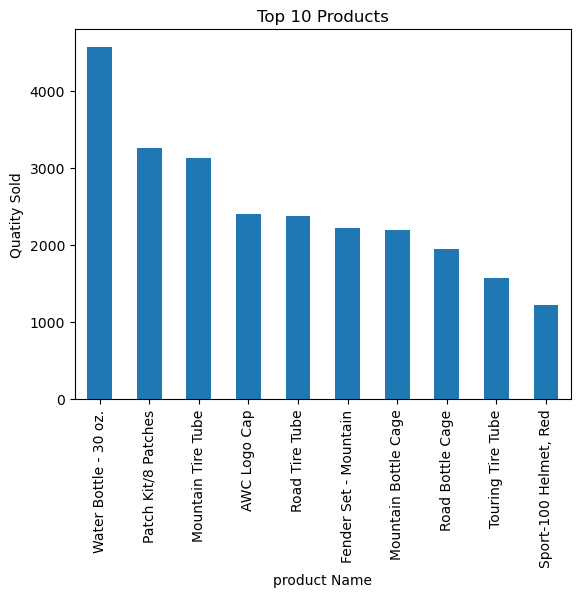

In [24]:
top_products.plot(kind="bar")
plt.title("Top 10 Products")
plt.xlabel("product Name")
plt.ylabel("Quatity Sold")
plt.show()

In [33]:
Sales_Country = pd.merge(
    Sales,
    Territory,
    left_on="TerritoryKey",
    right_on="SalesTerritoryKey"
)


In [37]:
Country_Sales = Sales_Country.groupby("Country")["OrderQuantity"].sum()

In [38]:
Country_Sales.sort_values(ascending=False)

Country
United States     16252
Australia          9487
Canada             5860
United Kingdom     5093
Germany            4386
France             4236
Name: OrderQuantity, dtype: int64

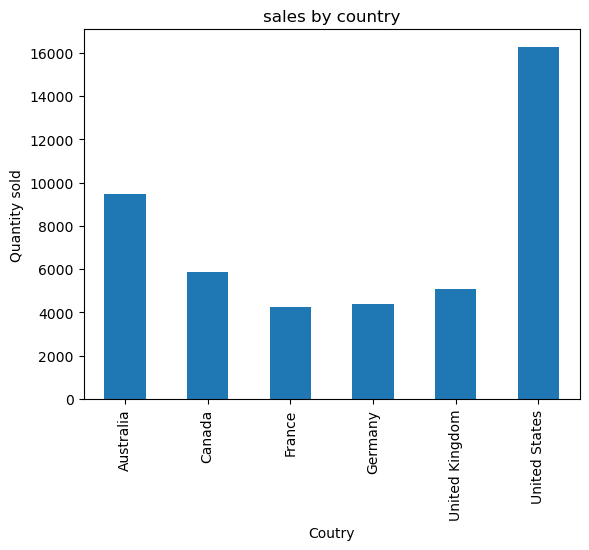

In [39]:
Country_Sales.plot(kind="bar")
plt.title("sales by country")
plt.xlabel("Coutry")
plt.ylabel("Quantity sold")
plt.show()

In [40]:
Sales["OrderDate"]= pd.to_datetime(Sales["OrderDate"])

In [41]:
monthly_sales = Sales.groupby(Sales["OrderDate"].dt.month)["OrderQuantity"].sum()

In [42]:
print(monthly_sales)

OrderDate
1    7020
2    6828
3    7327
4    7680
5    8199
6    8260
Name: OrderQuantity, dtype: int64


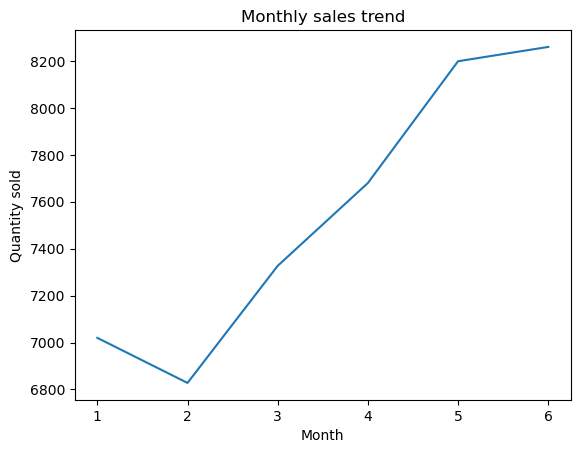

In [43]:
monthly_sales.plot()
plt.title("Monthly sales trend")
plt.xlabel("Month")
plt.ylabel("Quantity sold")
plt.show()